In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import combinations

SELECTED_CRIMES = ['Assault', 'Robbery', 'Fraud', 'Prostitution'] # Selected crimes for this part
N_COLS = 3 # Number of columns in the plot
N_ROWS = 2 # Number of rows in the plot

In [15]:
# Helper functions

def linear_fit_closed_form(x, y):
    '''
    Fit y = a*x + b with closed-form least squares; return (a, b) based on equations (1) and (2) from week 4, or (nan, nan) if x has zero variance.
    '''
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    n = len(x)

    x_mean = x.mean()
    y_mean = y.mean()

    numerator = np.sum(x * y) - n * x_mean * y_mean
    denominator = np.sum(x * x) - n * x_mean * x_mean

    if denominator == 0:
        return np.nan, np.nan

    a = numerator / denominator
    b = y_mean - a * x_mean
    return a, b


def r2_from_fit(x, y, a, b):
    '''
    Compute R^2 for y_hat = a*x + b based on equations on Coefficient of Determination Wikipedia page; return NaN if fit params are invalid or y has zero variance.
    '''
    if not np.isfinite(a) or not np.isfinite(b):
        return np.nan

    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    y_hat = a * x + b

    ssres = np.sum((y - y_hat) ** 2)
    sstot = np.sum((y - y.mean()) ** 2)

    if sstot == 0:
        return np.nan

    return 1 - ssres / sstot

In [16]:
df = pd.read_csv('../data/sf_crime_merged_focus_2003_2025.csv', usecols=['Focus Crime', 'Incident Date', 'Incident Time'])

# Build 168-hour weekly vectors per crime
df = df[df['Focus Crime'].isin(SELECTED_CRIMES)].copy() # Only keep selected crimes
df['Incident Date'] = pd.to_datetime(df['Incident Date'], errors='coerce') # Convert date text to real dates

# Extract hour from Incident Time, drop invalid rows and create HourOfWeek column
hour_str = df['Incident Time'].astype(str).str.extract(r'^(\d{1,2})')[0] 
df['Hour'] = pd.to_numeric(hour_str, errors='coerce') 
df = df.dropna(subset=['Incident Date', 'Hour'])
df['Hour'] = df['Hour'].astype(int).clip(0, 23)
df['HourOfWeek'] = df['Incident Date'].dt.dayofweek * 24 + df['Hour']

# Count number of incidents for a crime per hour
hourly_168 = (
    df.groupby(['HourOfWeek', 'Focus Crime'])
    .size()
    .rename('Count')
    .reset_index()
)

# Create a table with the number of incidents for each crime per hour
pivot = (
    hourly_168.pivot(index='HourOfWeek', columns='Focus Crime', values='Count')
    .reindex(range(168))
    .fillna(0)
    .reindex(columns=SELECTED_CRIMES, fill_value=0)
)

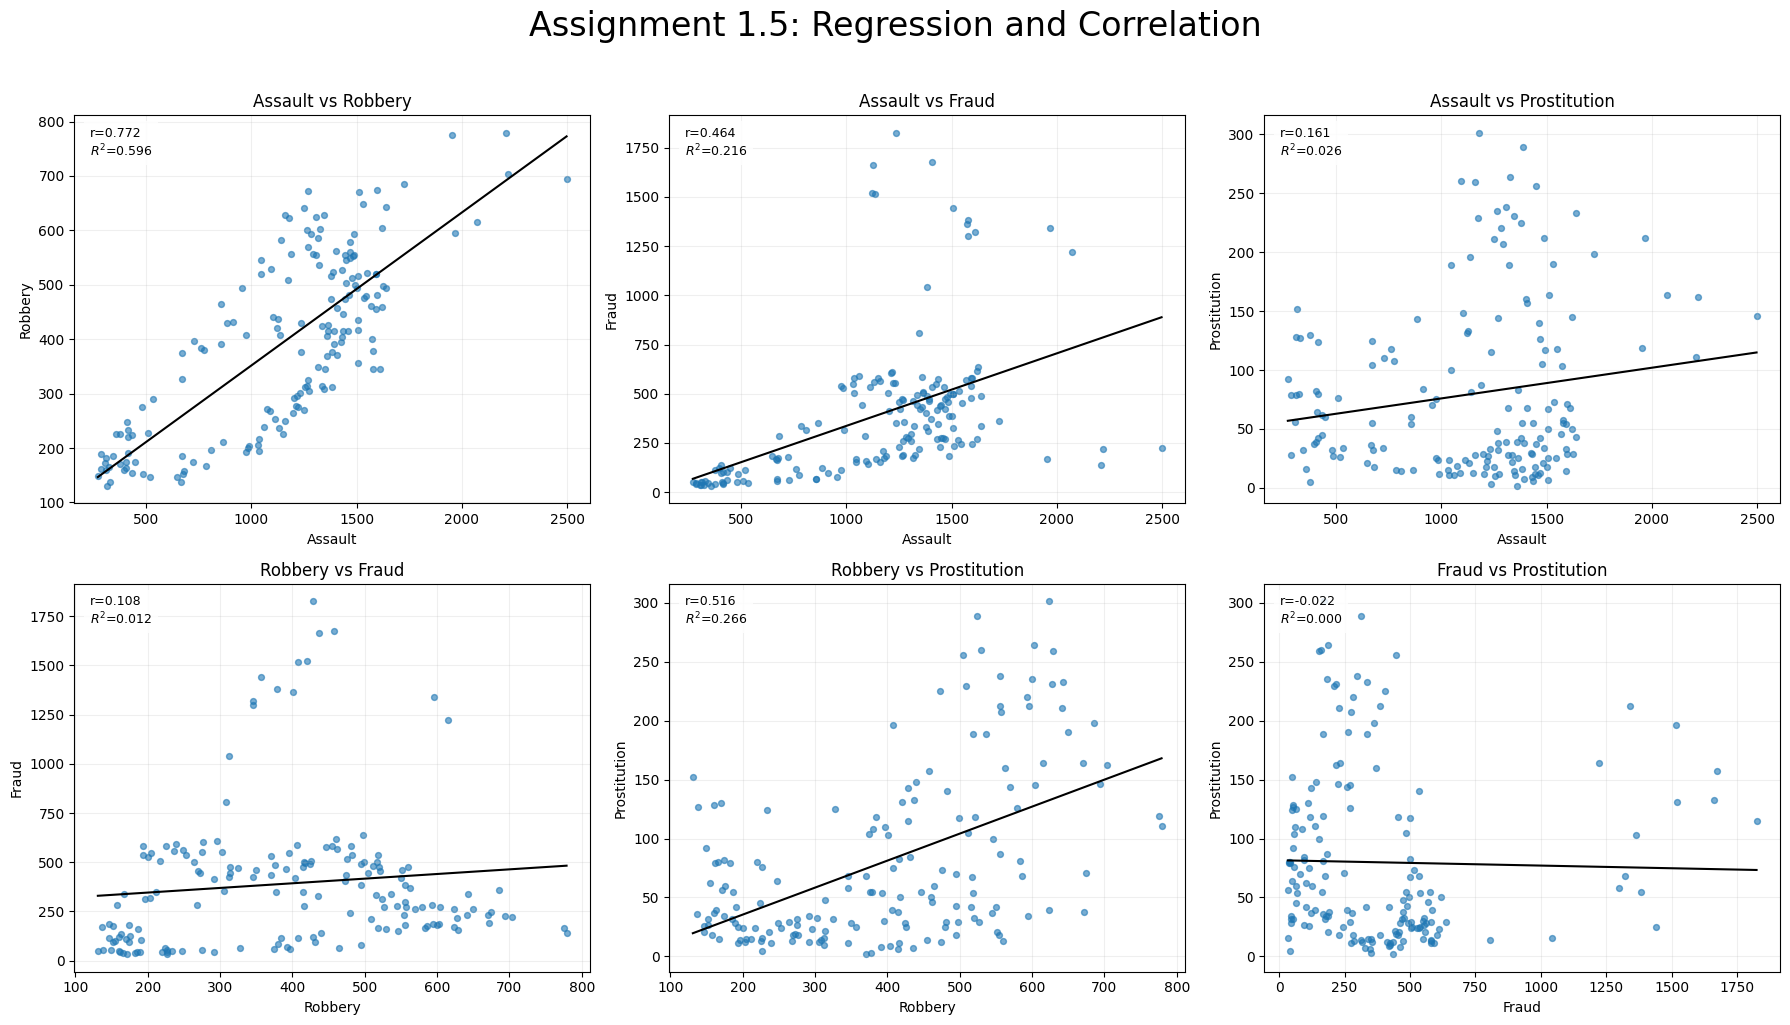

Pairwise results (sorted by R^2):
Crime A      Crime B      r    R2  a_slope  b_intercept
Assault      Robbery  0.772 0.596    0.282       69.819
Robbery Prostitution  0.516 0.266    0.229      -10.291
Assault        Fraud  0.464 0.216    0.369      -33.325
Assault Prostitution  0.161 0.026    0.026       49.839
Robbery        Fraud  0.108 0.012    0.236      298.423
  Fraud Prostitution -0.022 0.000   -0.005       81.565

Most correlated pair:
- Assault vs Robbery | r=0.772, R^2=0.596

Least correlated pair:
- Fraud vs Prostitution | r=-0.022, R^2=0.000


In [19]:
# Create a list of all possible pairs of crimes and set up the plot
pairs = list(combinations(SELECTED_CRIMES, 2))
n_pairs = len(pairs)
fig, axes = plt.subplots(N_ROWS, N_COLS, figsize=(6 * N_COLS, 5 * N_ROWS))
axes = np.atleast_1d(axes).ravel()
fig.suptitle('Assignment 1.5: Regression and Correlation', fontsize=24, y=1.02)

rows = [] # List to store the results

# Loop through each pair of crimes and plot the scatterplot and regression line
for ax, (crime_x, crime_y) in zip(axes, pairs):
    x = pivot[crime_x].to_numpy() # Convert the crime_x column to a numpy array
    y = pivot[crime_y].to_numpy() # Convert the crime_y column to a numpy array

    # Calculate the linear fit and R^2 for the pair of crimes
    a, b = linear_fit_closed_form(x, y)
    r2 = r2_from_fit(x, y, a, b)

    # Calculate the Pearson correlation coefficient for the pair of crimes
    if np.std(x) == 0 or np.std(y) == 0:
        r = np.nan
    else:
        r = np.corrcoef(x, y)[0, 1]

    # Store the results in our list
    rows.append({
        'Crime A': crime_x,
        'Crime B': crime_y,
        'a_slope': a,
        'b_intercept': b,
        'r': r,
        'R2': r2,
    })

    # Plot the scatterplot
    ax.scatter(x, y, s=18, alpha=0.6, color='tab:blue')

    # Plot the regression line
    x_line = np.linspace(x.min(), x.max(), 100)
    y_line = a * x_line + b
    ax.plot(x_line, y_line, color='black', linewidth=1.5)

    # Insert correlation coefficient and R^2 text into the top left corner of the plot
    ax.text(
        0.03,
        0.97,
        f'r={r:.3f}\n$R^2$={r2:.3f}',
        transform=ax.transAxes,
        va='top',
        fontsize=9,
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.85),
    )

    # Set the title, x-axis label, y-axis label, and grid
    ax.set_title(f'{crime_x} vs {crime_y}')
    ax.set_xlabel(crime_x)
    ax.set_ylabel(crime_y)
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()


# Print key findings
results = pd.DataFrame(rows).sort_values('R2', ascending=False).reset_index(drop=True)
most_correlated = results.iloc[0]
least_correlated = results.iloc[-1]

print('Pairwise results (sorted by R^2):')
print(
    results[['Crime A', 'Crime B', 'r', 'R2', 'a_slope', 'b_intercept']]
    .to_string(index=False, float_format=lambda v: f'{v:.3f}')
)

print('\nMost correlated pair:')
print(
    f"- {most_correlated['Crime A']} vs {most_correlated['Crime B']} "
    f"| r={most_correlated['r']:.3f}, R^2={most_correlated['R2']:.3f}"
)

print('\nLeast correlated pair:')
print(
    f"- {least_correlated['Crime A']} vs {least_correlated['Crime B']} "
    f"| r={least_correlated['r']:.3f}, R^2={least_correlated['R2']:.3f}"
)

Different crime types can follow different weekly patterns because they happen in different settings and are reported in different ways. Some crimes are linked more to nightlife and late hours, while others are often discovered and reported during daytime or work hours. Police focus in certain areas can also affect when incidents are recorded.

In our results, the most correlated pair is Assault vs Robbery (**$R^2$**=0.596). These crimes are more similar in nature and both involve direct personal contact, so it makes sense that their weekly rhythm is relatively close. The least correlated pair is Fraud vs Prostitution (**$R^2$**=−0.005), which also makes sense because these two crimes are very different in both behavior and reporting pattern.

A key conclusion is that weekly timing gives important information that total incident counts alone cannot show. Two crimes can have similar totals but completely different hourly patterns, while other crimes can move together during the same parts of the week. Because of this, understanding crime patterns requires looking at context, time-of-week behavior, and reporting dynamics, not just the raw number of incidents.